In [235]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [236]:
df1 = pd.read_csv('sample_submission.csv') 
df1.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [237]:
df2 = pd.read_csv('test.csv')
df2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### As the Target variables is Sales price which is present in "sample_submission.csv" not in "test.csv" --> combined together

In [238]:
# Merge beased on Id
df = pd.merge(df2,df1, on ="Id") 
# Save combined dataset
df.to_csv("housing_full.csv", index=False)

In [239]:
df = pd.read_csv("housing_full.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,169277.052498
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,187758.393989
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,183583.683570
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,179317.477511
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,150730.079977


## EDA (Exploratory Data Analysis)

In [240]:
df.shape

(1459, 81)

In [241]:
# drop the Id column as it is not necessary for model training.
df.drop(columns=['Id'],inplace=True)

In [242]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,169277.052498
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,187758.393989
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,183583.683570
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,179317.477511
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,150730.079977


In [243]:
df.shape

(1459, 80)

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuil

## Missing Values Analysis

In [245]:
# Missing values summary 
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(f"Features with missing values: {len(missing_df)}")
missing_df

Features with missing values: 33


,Count,Percent
PoolQC,1456,99.79
MiscFeature,1408,96.50
Alley,1352,92.67
Fence,1169,80.12
MasVnrType,894,61.27
FireplaceQu,730,50.03
LotFrontage,227,15.56
GarageCond,78,5.35
GarageYrBlt,78,5.35
GarageQual,78,5.35


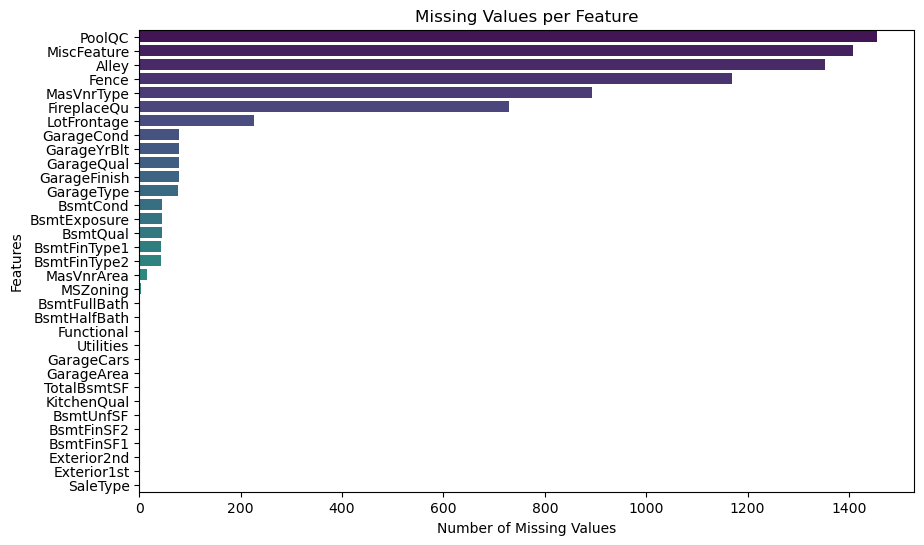

In [246]:
# Bar plot of missing values
plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_df["Count"], 
    y=missing_df.index, 
    orient="h", 
    palette="viridis"
)

plt.title("Missing Values per Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Features")
plt.show()

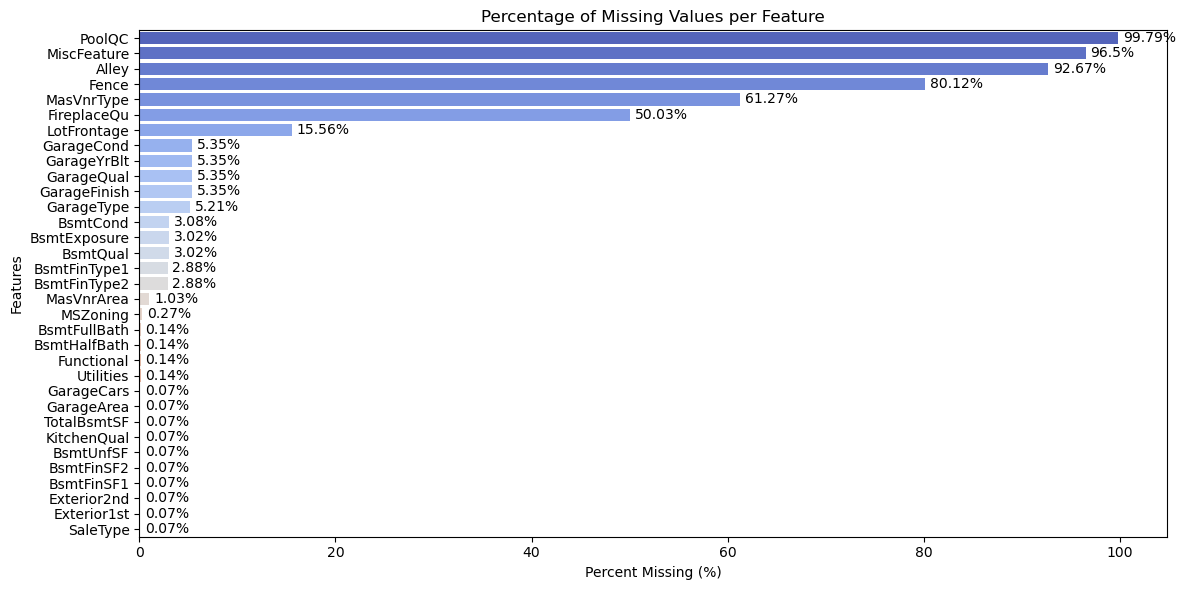

In [247]:
plt.figure(figsize=(12,6))

# Bar plot with percentage on x-axis
ax = sns.barplot(
    x=missing_df["Percent"], 
    y=missing_df.index, 
    orient="h", 
    palette="coolwarm"
)
# Add percentage labels on each bar
for i, (value, name) in enumerate(zip(missing_df["Percent"], missing_df.index)):
    ax.text(value + 0.5, i, f"{value}%", va="center")

plt.title("Percentage of Missing Values per Feature")
plt.xlabel("Percent Missing (%)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Handle Missing Values

In [248]:
df.shape

(1459, 80)

In [249]:
# 1. Categorical features where NA means "None" (feature absent)
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

# 2. Numerical features where NA means 0 (no feature)
zero_cols = ['GarageYrBlt','GarageArea','GarageCars',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# 3. LotFrontage -->  fill by neighborhood median
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# 4. Remaining categorical --> fill with mode (most frequent value)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Remaining numerical -->  fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Final check
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("All missing values handled!")

Remaining missing values: 0
All missing values handled!


## Numerical Features vs SalePrice

In [250]:
cleaned_df = df.copy()

# select numeric features 
numeric_feats = cleaned_df.select_dtypes(include=[np.number]).columns
# Calculate correlations with SalePrice 
correlations = cleaned_df[numeric_feats].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False) 
# print strongest 15 
print(correlations.head(15).to_string())

BedroomAbvGr    0.786022
LotArea         0.715795
TotRmsAbvGrd    0.625592
GrLivArea       0.566654
LotFrontage     0.458090
1stFlrSF        0.339335
2ndFlrSF        0.330785
FullBath        0.326312
GarageArea      0.250677
MoSold          0.239906
GarageCars      0.233109
HalfBath        0.223001
Fireplaces      0.213041
TotalBsmtSF     0.210655
MSSubClass      0.205917


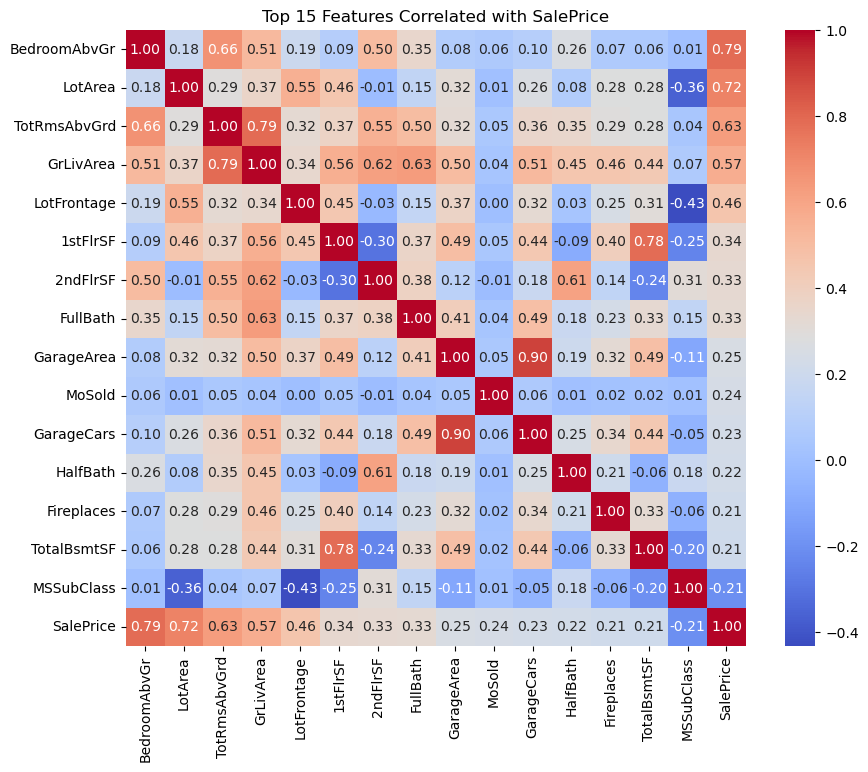

In [251]:
# Correlation heatmap — top 15 features
# select top 15 features
top15 = correlations.head(15).index

# create correlation matrix for those features + SalePrice
corr_matrix = cleaned_df[top15.tolist() + ['SalePrice']].corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top 15 Features Correlated with SalePrice")
plt.show()

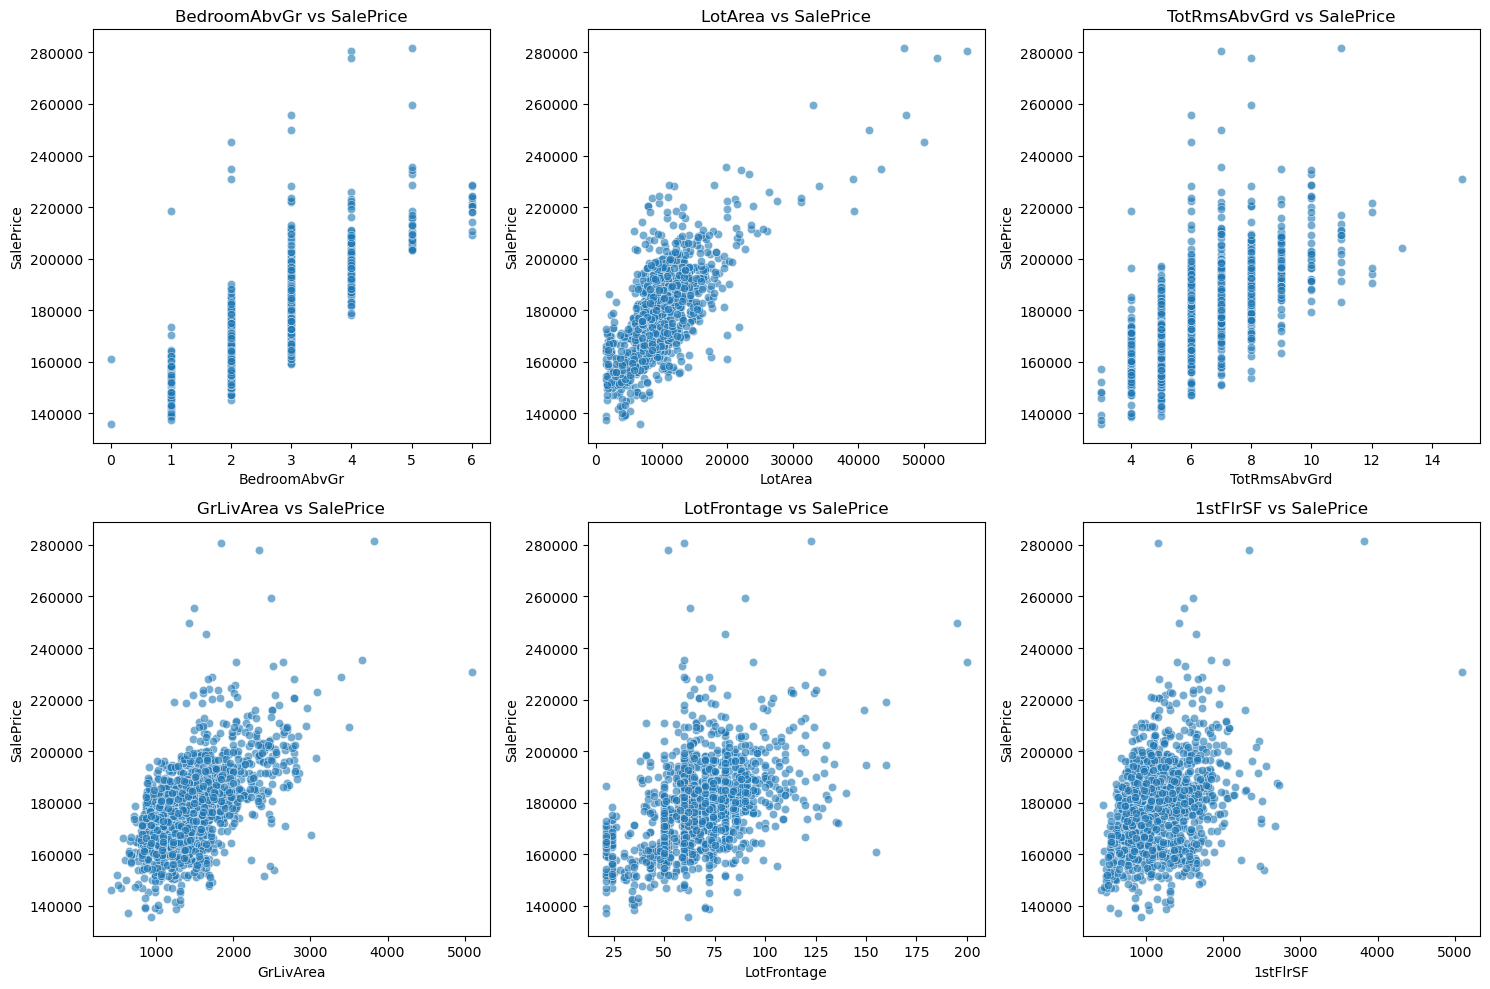

In [252]:
# Scatter plots: Top 6 features vs SalePrice

#pick top 6 features
top6 = correlations.head(6).index

# scatter plots
plt.figure(figsize=(15,10))

for i, col in enumerate(top6, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns grid
    sns.scatterplot(x=cleaned_df[col], y=cleaned_df['SalePrice'], alpha=0.6)
    plt.title(f"{col} vs SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")

plt.tight_layout()
plt.show()

## Categorical Features vs SalePrice

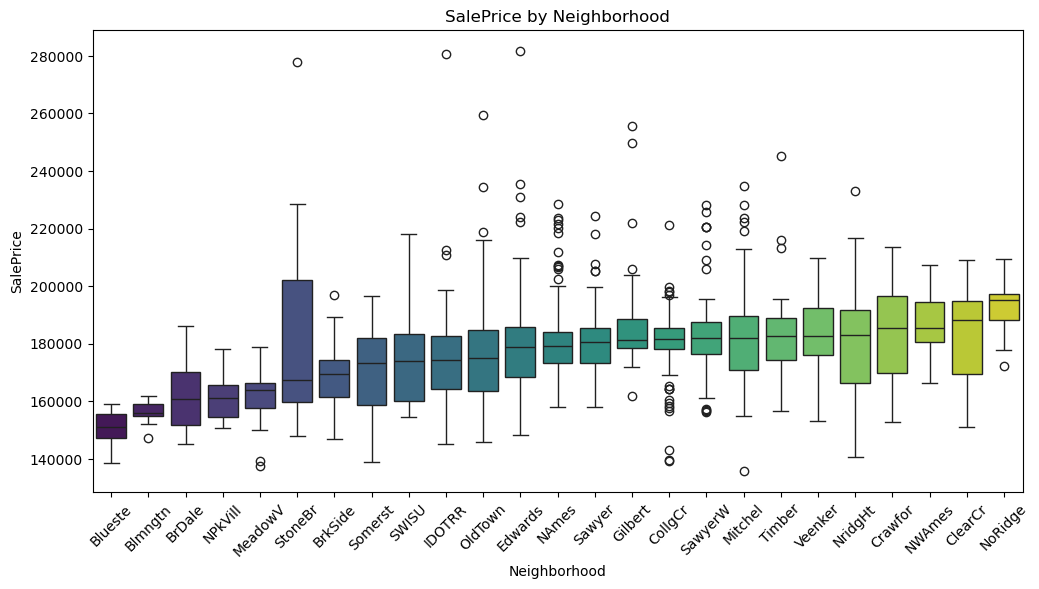

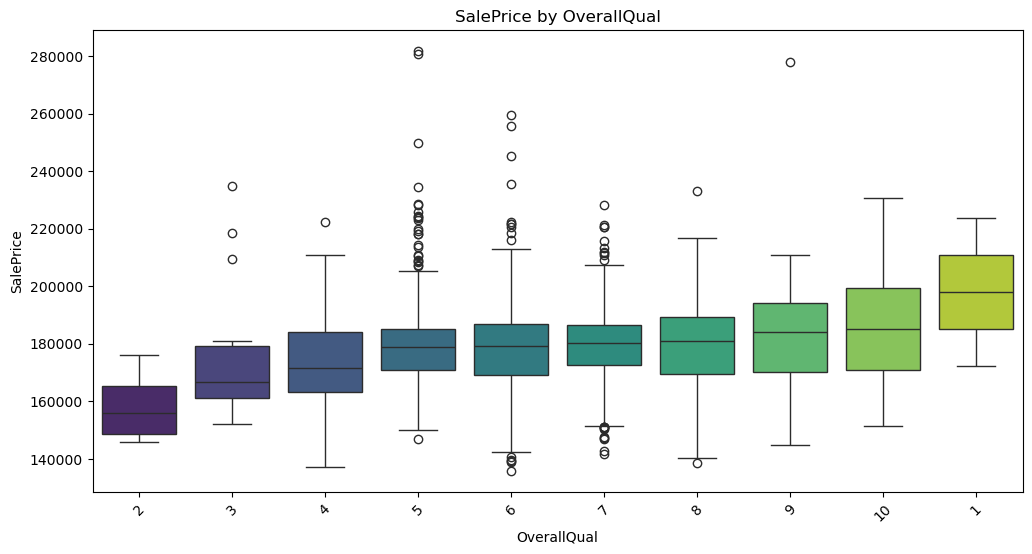

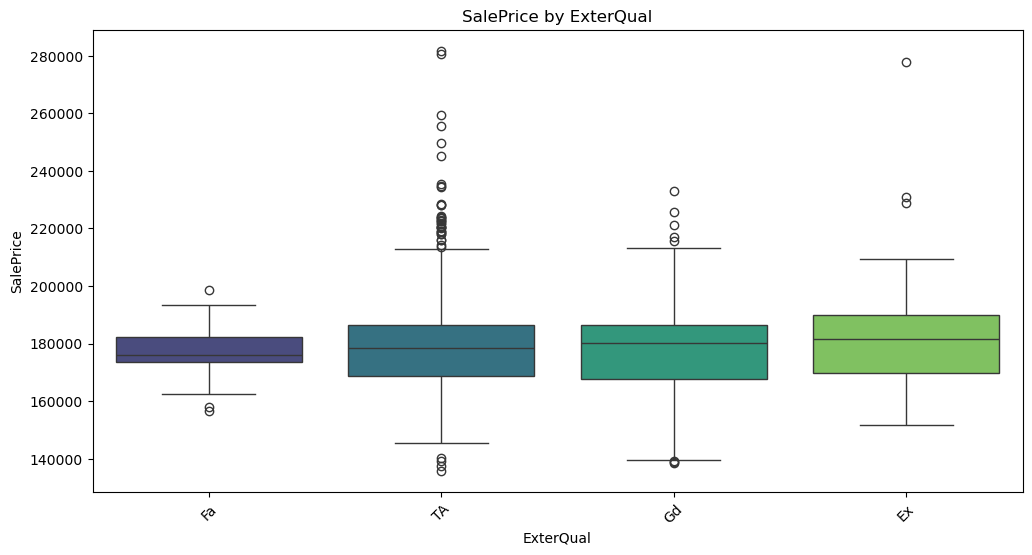

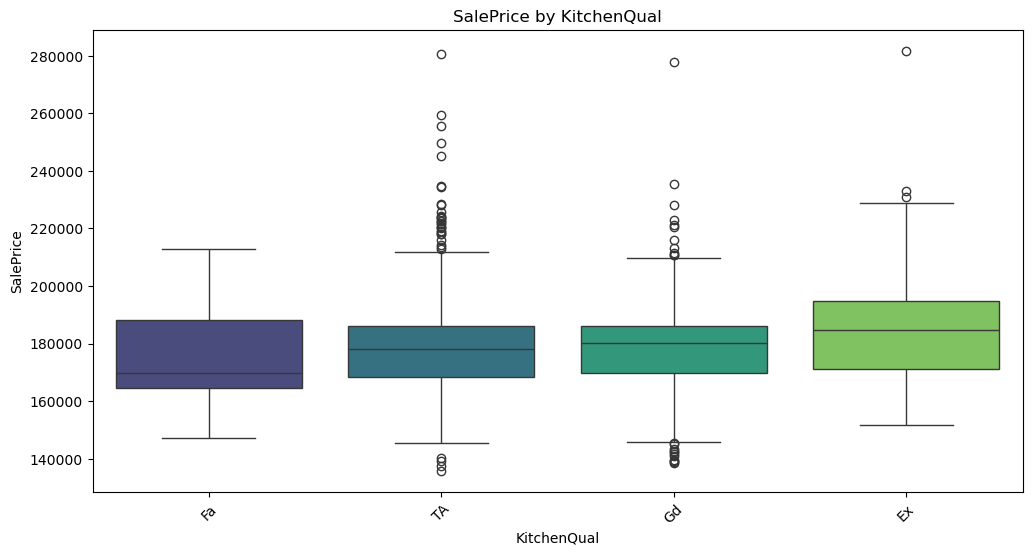

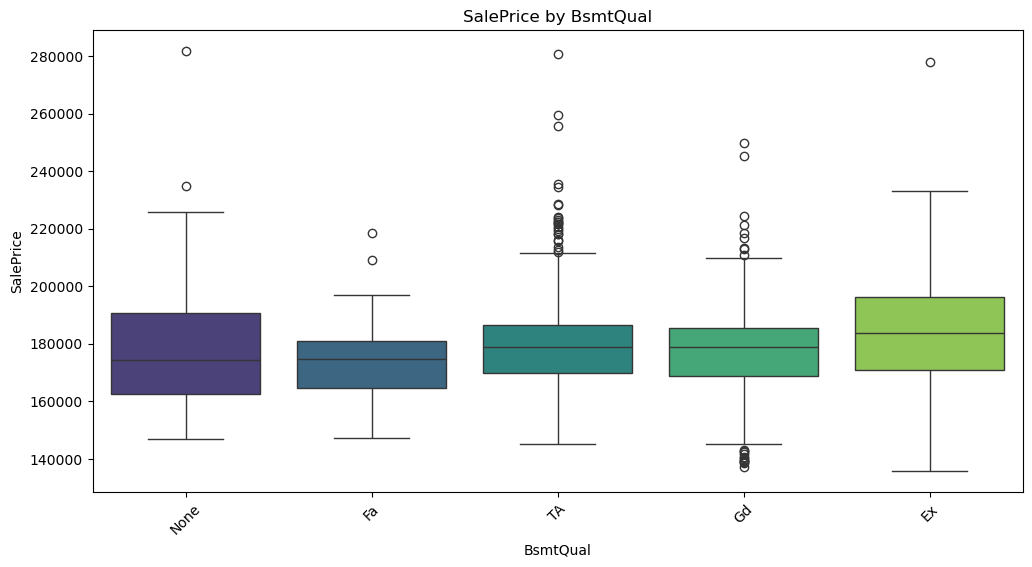

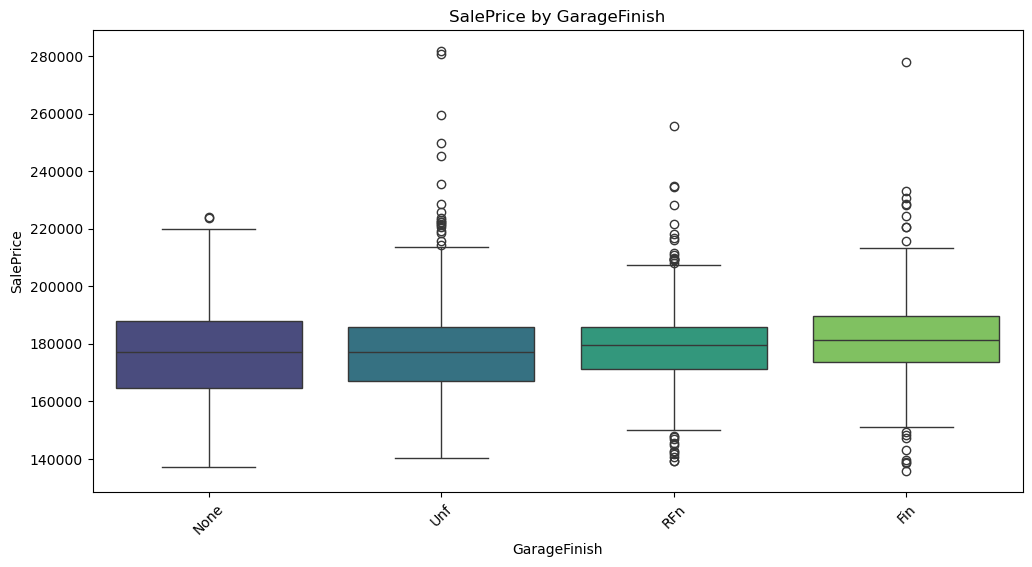

In [253]:
# These are categorical (or ordinal) features that likely influence house prices. 
cat_feats = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(x='Neighborhood', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by Neighborhood')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('OverallQual')['SalePrice'].median().sort_values().index
sns.boxplot(x='OverallQual', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by OverallQual')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('ExterQual')['SalePrice'].median().sort_values().index
sns.boxplot(x='ExterQual', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by ExterQual')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('KitchenQual')['SalePrice'].median().sort_values().index
sns.boxplot(x='KitchenQual', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by KitchenQual')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('BsmtQual')['SalePrice'].median().sort_values().index
sns.boxplot(x='BsmtQual', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by BsmtQual')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
order = cleaned_df.groupby('GarageFinish')['SalePrice'].median().sort_values().index
sns.boxplot(x='GarageFinish', y='SalePrice', data=cleaned_df, order=order, palette='viridis')
plt.title('SalePrice by GarageFinish')
plt.xticks(rotation=45)
plt.show()


### House Price Distribution

In [254]:
print(cleaned_df['SalePrice'].describe())

count      1459.000000
mean     179183.918243
std       16518.303051
min      135751.318893
25%      168703.011202
50%      179208.665698
75%      186789.409363
max      281643.976117
Name: SalePrice, dtype: float64


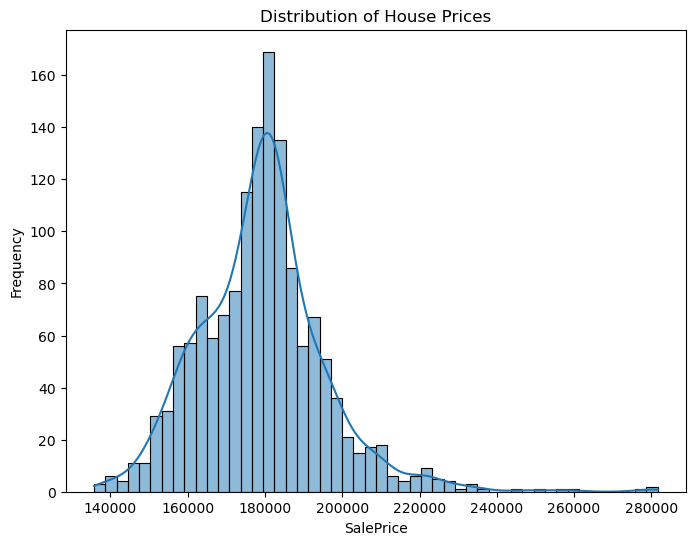

In [255]:
plt.figure(figsize=(8,6))
sns.histplot(cleaned_df['SalePrice'],kde=True, bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

### Key Numerical features distribution

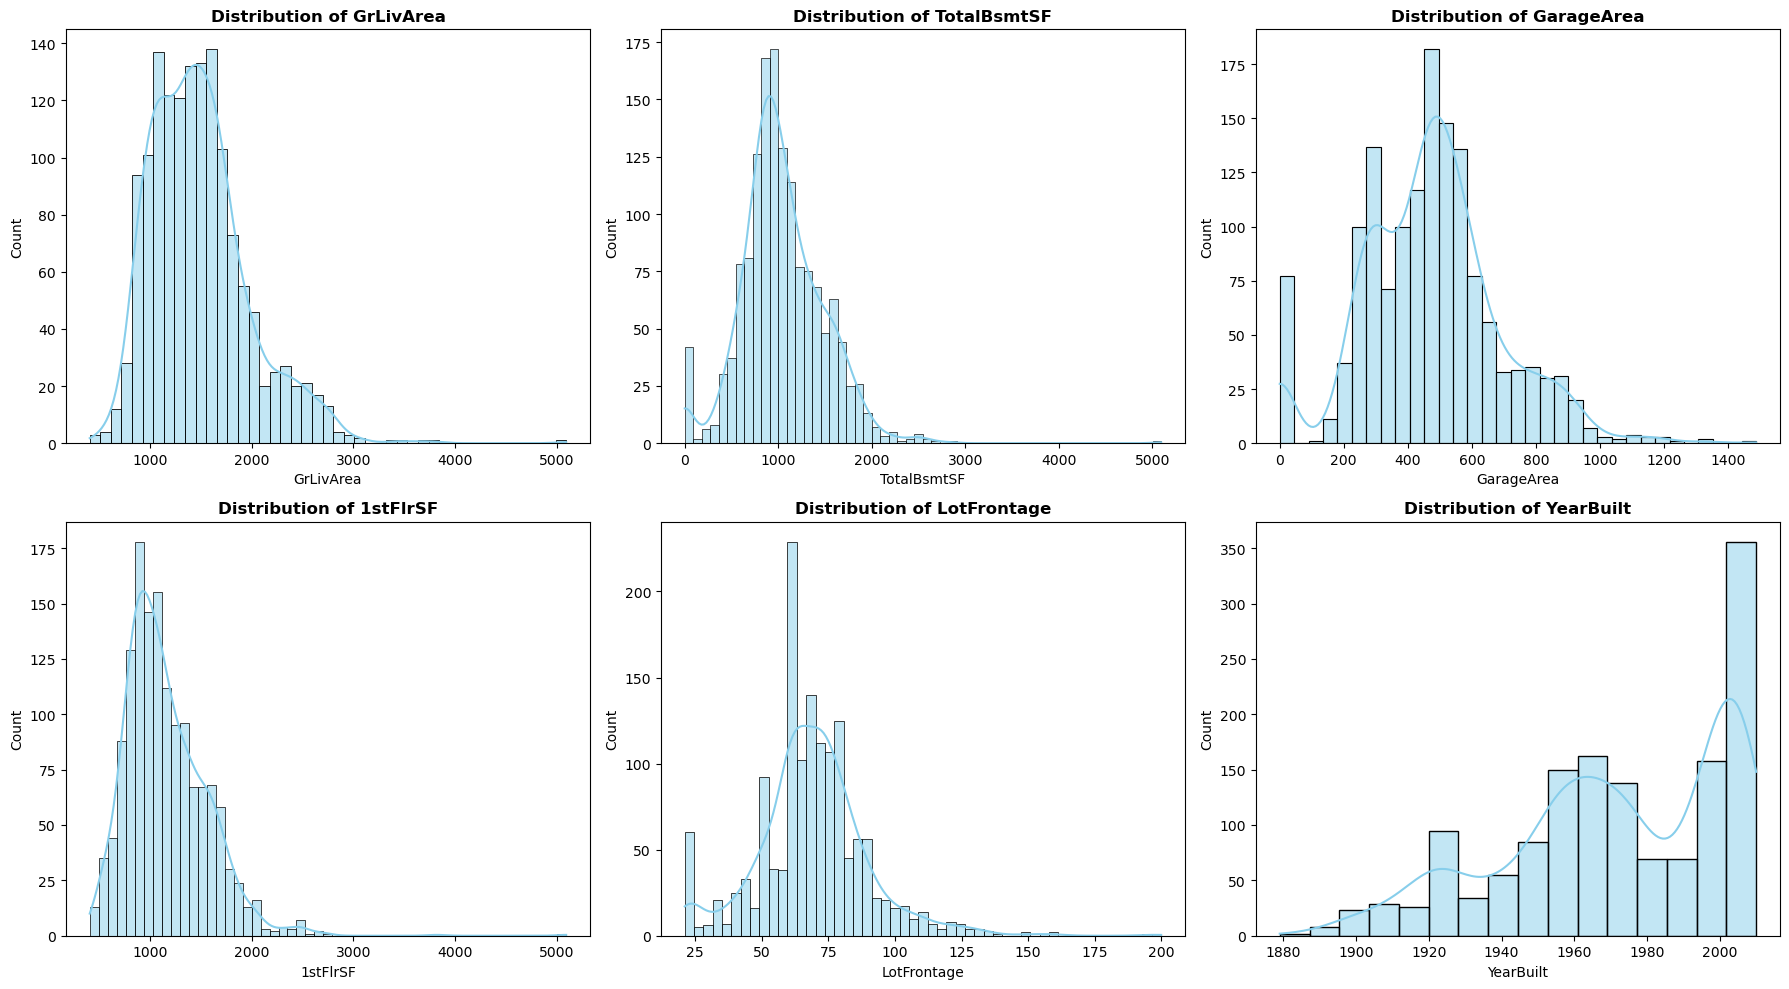

In [256]:
# Pick key numerical features
num_feats = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'LotFrontage', 'YearBuilt']

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, feat in enumerate(num_feats):
    ax = axes[i//3, i%3]   # position in grid
    sns.histplot(cleaned_df[feat], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {feat}', fontweight='bold')

plt.tight_layout()

## Year Features Analysis

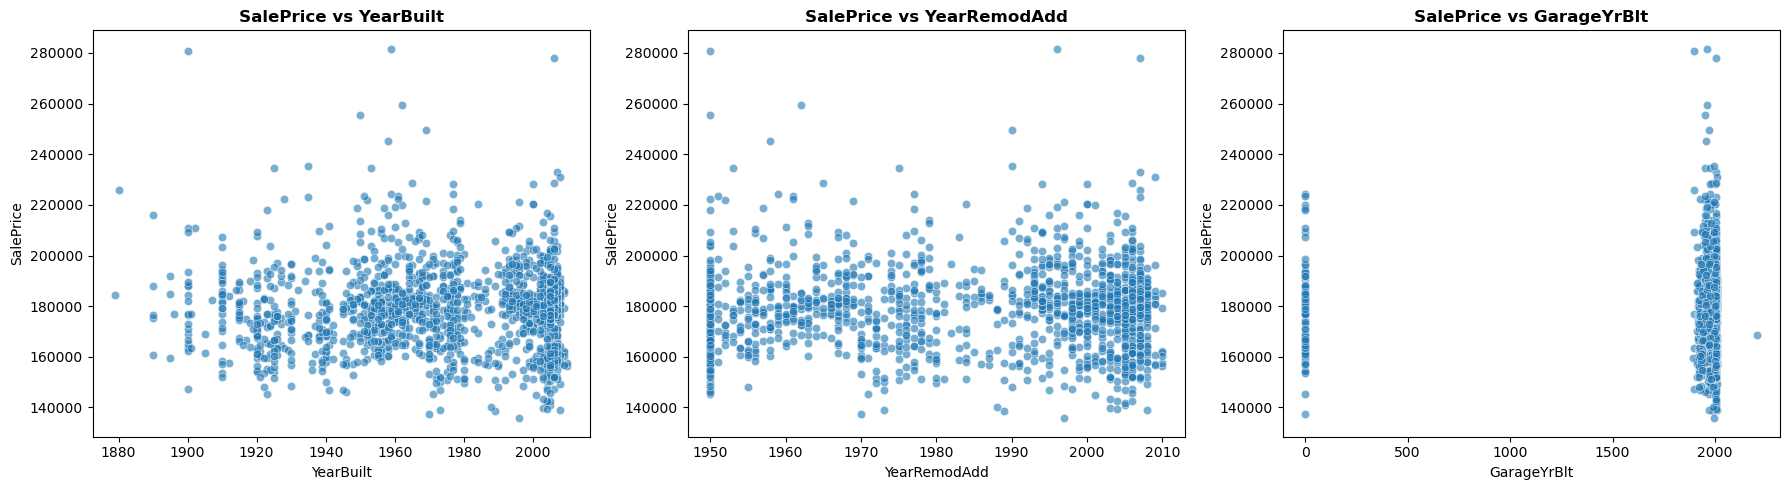

In [257]:
# YearBuilt --> when the house was originally built.
# YearRemodAdd --> when it was remodeled or added.
# GarageYrBlt --> year garage was built.

year_feats = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(year_feats):
    ax = axes[i]
    sns.scatterplot(x=cleaned_df[feat], y=cleaned_df['SalePrice'], alpha=0.6, ax=ax)
    ax.set_title(f'SalePrice vs {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

## Sales over Time

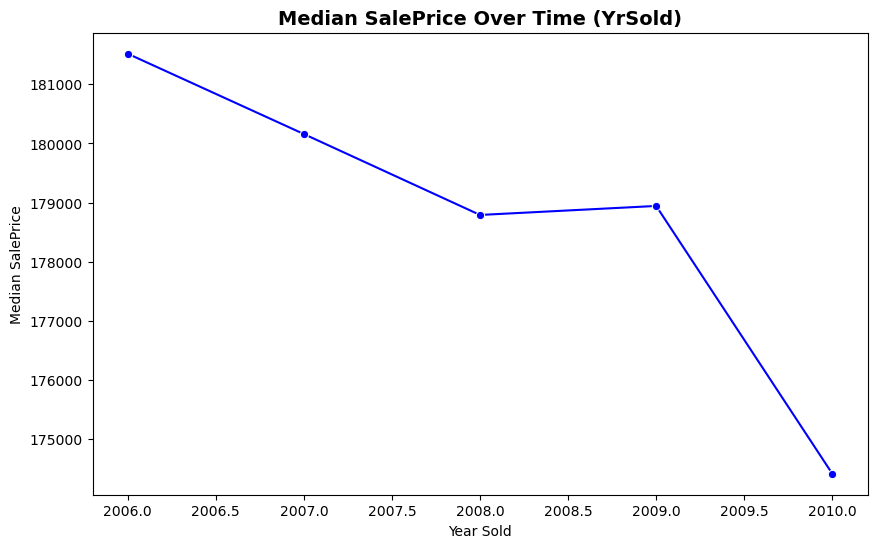

In [258]:
# Group by year sold and calculate median SalePrice
sales_trend = cleaned_df.groupby('YrSold')['SalePrice'].median()

plt.figure(figsize=(10,6))
sns.lineplot(x=sales_trend.index, y=sales_trend.values, marker='o', color='blue')
plt.title('Median SalePrice Over Time (YrSold)', fontsize=14, fontweight='bold')
plt.xlabel('Year Sold')
plt.ylabel('Median SalePrice')
plt.show()

##  Outlier Detection & Treatment

In [259]:
# Detect Outliers (IQR Method)
# Calculate IQR
Q1 = cleaned_df['GrLivArea'].quantile(0.25)
Q3 = cleaned_df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = cleaned_df[(cleaned_df['GrLivArea'] < lower_bound) | (cleaned_df['GrLivArea'] > upper_bound)]

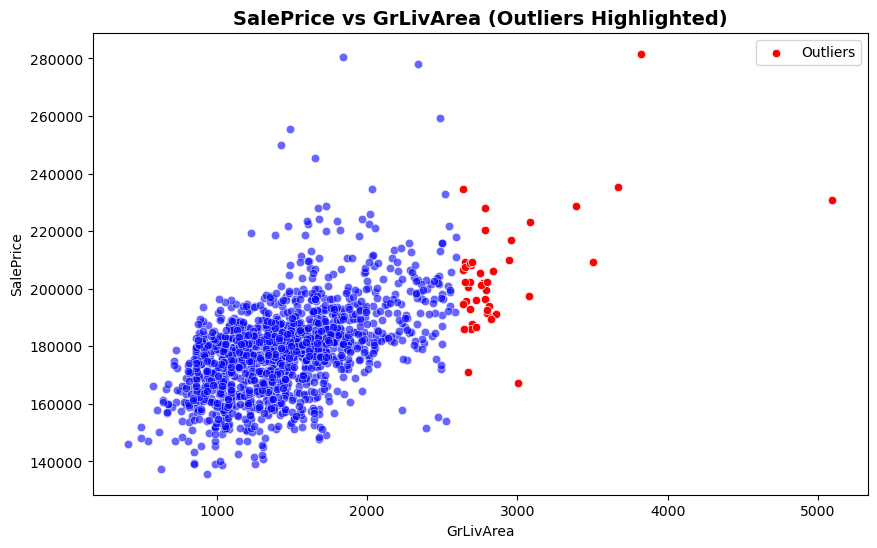

In [260]:
# Highlight Outliers with Scatter Plot

plt.figure(figsize=(10,6))
sns.scatterplot(x=cleaned_df['GrLivArea'], y=cleaned_df['SalePrice'], alpha=0.6, color='blue')

# Highlight outliers in red
sns.scatterplot(x=outliers['GrLivArea'], y=outliers['SalePrice'], color='red', label='Outliers')

plt.title('SalePrice vs GrLivArea (Outliers Highlighted)', fontsize=14, fontweight='bold')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.show()


In [261]:
# Remove outliers
df_no_outliers = cleaned_df[
    (cleaned_df['GrLivArea'] >= lower_bound) &
    (cleaned_df['GrLivArea'] <= upper_bound)
]

print("Original shape:", cleaned_df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (1459, 80)
After removing outliers: (1415, 80)


## Feature Engineering

In [262]:
# Copy dataset
df = cleaned_df.copy()
df.shape

(1459, 80)

In [263]:
df['ExterQual'].unique()

array(['TA', 'Gd', 'Ex', 'Fa'], dtype=object)

In [264]:
df['KitchenQual'].unique()

array(['TA', 'Gd', 'Ex', 'Fa'], dtype=object)

In [265]:
df['BsmtQual'].unique()

array(['TA', 'Gd', 'Ex', 'Fa', 'None'], dtype=object)

In [266]:
# encode categorical data 
# Map quality features to numeric scores
quality_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
for feat in ['ExterQual','KitchenQual','BsmtQual']:
    if feat in df.columns:
        df[feat] = df[feat].map(quality_map)

In [267]:
# One-hot encode Neighborhood & GarageFinish
df = pd.get_dummies(df, columns=['Neighborhood','GarageFinish'], drop_first=True)

In [268]:
df.shape

(1459, 105)

In [269]:
from sklearn.preprocessing import MinMaxScaler
# Scale Numerical Features
scaler = MinMaxScaler()
scale_feats = ['GrLivArea','TotalBsmtSF','GarageArea','LotFrontage','1stFlrSF']
df[scale_feats] = scaler.fit_transform(df[scale_feats])

In [270]:
# Create New Features 
# Total square footage
df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF'] + df['1stFlrSF']

# House age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Remodeled indicator
df['Remodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

In [271]:
# Feature Selection 
# Drop redundant or highly correlated features
if 'GarageCars' in df.columns:
    df.drop('GarageCars', axis=1, inplace=True)

In [272]:
# Final engineered dataset
print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (1459, 107)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,TotalSF,HouseAge,Remodeled
0,20,RH,0.329609,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,False,False,False,False,False,False,True,0.381729,49,0
1,20,RL,0.335196,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,False,False,False,False,False,False,True,0.654189,52,0
2,60,RL,0.296089,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,False,False,False,False,False,False,False,0.553940,13,1
3,60,RL,0.318436,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,False,False,False,False,False,False,False,0.547788,12,0
4,120,RL,0.122905,5005,Pave,None,IR1,HLS,AllPub,Inside,...,False,True,False,False,False,True,False,0.623667,18,0


In [273]:
df['Utilities'].unique()

array(['AllPub'], dtype=object)

In [276]:
# Drop constant features (only one unique value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Constant features:", constant_cols)

df.drop(columns=constant_cols, inplace=True)
print("Shape after dropping constant features:", df.shape)

Constant features: []
Shape after dropping constant features: (1459, 106)


In [277]:
df['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)